# Testes Iniciais — Avaliação CEP + ML
## Classificação de variedades de grãos de feijão (Dry Bean Dataset)

Maria Eduarda Lobo Montenegro — matrícula 200033972
Universidade de Brasília — Departamento de Engenharia de Produção
Disciplina de Controle Estatístico de Processos
Prof. Andre Luiz Marques Serrano
Abril de 2026

---

Este é o primeiro entregável parcial do projeto. O objetivo aqui é só mostrar que escolhi um dataset, que ele carrega corretamente no Colab e que eu consigo extrair as primeiras leituras dele — distribuição da target, estatísticas descritivas e correlações entre as features. As partes de CEP propriamente dita (cartas de controle e índices de capacidade) e a modelagem de machine learning ficam para os próximos entregáveis.

### Sobre a escolha do dataset

Para esta avaliação, decidi trabalhar com o **Dry Bean Dataset**, publicado por Koklu & Ozkan (2020) e disponível no UCI Machine Learning Repository (id=602). A motivação foi manter um paralelo metodológico com o modelo de Steel Plates Faults discutido em aula — problema multiclasse, features extraídas de imagem, contexto de controle de qualidade — mas migrando de domínio (siderurgia para agroindústria), o que me obriga a interpretar os resultados com cuidado em vez de simplesmente replicar conclusões.

São 13.611 grãos individuais, fotografados por uma câmera de alta resolução em uma linha de classificação, com 16 medidas morfológicas extraídas por algoritmos de visão computacional e 7 variedades comerciais como rótulo (target). Antes de começar, confesso que escolhi esse dataset também pensando no agronegócio brasileiro — somos um país produtor relevante e a inspeção manual de grãos ainda é uma realidade em boa parte das cooperativas.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/melobomontenegro-dev/CEP_Projeto_Maria_Eduarda/blob/main/testes_iniciais.ipynb)

## Configuração do ambiente

O dataset é carregado diretamente do UCI por meio do pacote oficial `ucimlrepo`. Isso garante que qualquer pessoa que abrir esse notebook obtenha exatamente os mesmos dados — não há CSV solto no repositório, nem dependência de download manual.

In [1]:
!pip install -q ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Paleta de cores da UnB (verde-bandeira e azul-marinho)
UNB_VERDE = '#006633'
UNB_AZUL = '#003366'
UNB_AREIA = '#d9d2b6'
PALETA_UNB = [UNB_VERDE, UNB_AZUL, '#8a9a5b', '#4a6b3a', '#5b7c99', '#2c4a6b', '#736b3f']

sns.set_style('white')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.edgecolor'] = '#4a4a4a'
plt.rcParams['axes.labelcolor'] = '#2c2c2c'

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
np.random.seed(42)

## 1. Carregamento do dataset

Faço o download direto do UCI. O retorno do `fetch_ucirepo` já separa features (X) e target (y) — junto os dois num único DataFrame só para facilitar a inspeção visual nas próximas células.

In [3]:
dry_bean = fetch_ucirepo(id=602)
X = dry_bean.data.features
y = dry_bean.data.targets
df = pd.concat([X, y], axis=1)

print(f'Dataset carregado: {df.shape[0]} amostras, {df.shape[1]} colunas no total')
print(f'Features morfologicas: {X.shape[1]}')
print(f'Variedades distintas: {y.iloc[:, 0].nunique()}')

Dataset carregado: 13611 amostras, 17 colunas no total
Features morfologicas: 16
Variedades distintas: 7


## 2. Inspeção inicial

Antes de qualquer análise, sempre dou uma olhada na "cara" dos dados: tipos das colunas, presença de valores ausentes, distribuição inicial das primeiras linhas. Em projetos anteriores já aprendi que pular essa etapa custa caro depois — é onde costumam aparecer os problemas silenciosos (string onde devia ser número, encoding estranho, NaN escondido como zero).

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRatio      13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  Roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [5]:
# Verificacao de valores ausentes
ausentes = df.isnull().sum()
total_ausentes = ausentes.sum()

if total_ausentes == 0:
    print('Nenhum valor ausente em nenhuma coluna.')
else:
    print(ausentes[ausentes > 0])
    print(f'\nTotal de ausentes no dataset: {total_ausentes}')

Nenhum valor ausente em nenhuma coluna.


In [6]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


Não foi preciso fazer nenhuma limpeza estrutural. Todas as 16 features são numéricas (`float64` ou `int64`), a coluna `Class` é a única categórica, e não há valores ausentes em lugar nenhum. Esse dataset chega bem mais "limpo" do que o típico — algo que faz sentido considerando que ele foi montado especificamente para fins de pesquisa em ML.

## 3. Distribuição da variável-alvo

Aqui o objetivo é entender o balanceamento entre as classes. Pelo livro do Montgomery (Cap. 4, sobre amostragem) e pela discussão das aulas, classes muito desbalanceadas tornam métricas como acurácia enganosas — um modelo que sempre prevê a classe majoritária pode ter "acurácia alta" sem ter aprendido nada útil.

Por isso quero ver, antes de qualquer modelagem, o quanto cada variedade aparece no dataset.

In [7]:
target_col = y.columns[0]
contagem = df[target_col].value_counts()
proporcao = (contagem / len(df) * 100).round(2)

dist = pd.DataFrame({'Amostras': contagem, 'Proporcao (%)': proporcao})
print(dist)
print(f'\nTotal: {len(df)} amostras')
print(f'Razao majoritaria/minoritaria: {contagem.max() / contagem.min():.2f}x')

          Amostras  Proporcao (%)
Class                            
DERMASON      3546          26.05
SIRA          2636          19.37
SEKER         2027          14.89
HOROZ         1928          14.17
CALI          1630          11.98
BARBUNYA      1322           9.71
BOMBAY         522           3.84

Total: 13611 amostras
Razao majoritaria/minoritaria: 6.79x


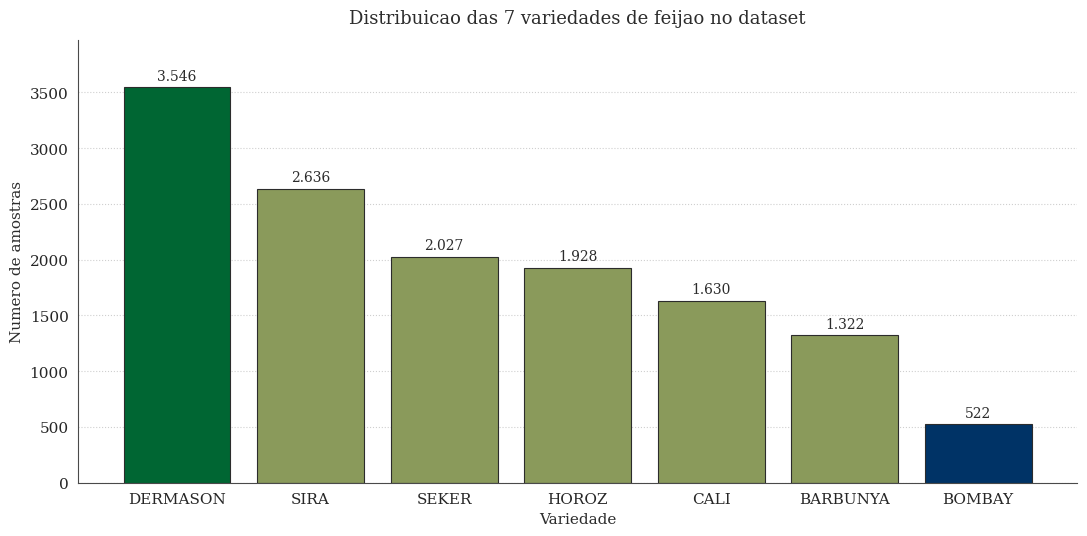

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5))
cores = [UNB_VERDE if c == contagem.idxmax() else
         UNB_AZUL if c == contagem.idxmin() else '#8a9a5b'
         for c in contagem.index]

barras = ax.bar(contagem.index, contagem.values, color=cores, edgecolor='#2c2c2c', linewidth=0.8)

for barra, valor in zip(barras, contagem.values):
    ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 40,
            f'{valor:,}'.replace(',', '.'),
            ha='center', va='bottom', fontsize=10, color='#2c2c2c')

ax.set_title('Distribuicao das 7 variedades de feijao no dataset', fontsize=13, color='#2c2c2c', pad=12)
ax.set_xlabel('Variedade', fontsize=11)
ax.set_ylabel('Numero de amostras', fontsize=11)
ax.set_ylim(0, contagem.max() * 1.12)
ax.grid(axis='y', linestyle=':', alpha=0.4, color='#888')
plt.tight_layout()
plt.show()

DERMASON aparece com cerca de 26% das amostras e BOMBAY com apenas 3,8% — uma razão de aproximadamente 7 vezes entre a classe mais comum e a mais rara. Isso é desbalanceamento, mas dentro de uma faixa que ainda permite trabalhar sem técnicas pesadas de oversampling (SMOTE, ADASYN). A decisão que já consigo tomar a partir daqui é que **vou usar F1-macro como métrica principal na modelagem**, e não acurácia — o macro pondera as 7 classes igualmente, o que protege contra o viés da classe majoritária.

Uma coisa que já me preocupa é o BOMBAY. Por ser a variedade fisicamente maior (consideravelmente maior, como vamos ver nas estatísticas), ela tende a aparecer como outlier na maioria dos critérios estatísticos. Vou precisar tomar cuidado na hora de remover outliers — talvez aplicar Z-score por classe em vez de globalmente. Anoto isso aqui para retomar no entregável de preparação de dados.

## 4. Estatísticas descritivas

Calculo as estatísticas básicas (média, desvio padrão, mínimos e máximos) e adiciono uma coluna de **coeficiente de variação (CV%)**, que é o desvio padrão dividido pela média em percentual. O CV é interessante porque normaliza a variabilidade pelo nível — features com magnitudes diferentes ficam comparáveis.

In [9]:
estat = df.describe().T[['mean', 'std', 'min', 'max']]
estat['CV (%)'] = (estat['std'] / estat['mean'] * 100).round(2)
estat = estat.round(3)
estat.columns = ['Media', 'Desvio padrao', 'Minimo', 'Maximo', 'CV (%)']
estat_ordenada = estat.sort_values('CV (%)', ascending=False)
estat_ordenada

,Media,Desvio padrao,Minimo,Maximo,CV (%)
ConvexArea,53768.200,29774.916,20684.000,263261.000,55.38
Area,53048.285,29324.096,20420.000,254616.000,55.28
ShapeFactor2,0.002,0.001,0.001,0.004,34.73
MajorAxisLength,320.142,85.694,183.601,738.860,26.77
Perimeter,855.283,214.290,524.736,1985.370,25.05
EquivDiameter,253.064,59.177,161.244,569.374,23.38
MinorAxisLength,202.271,44.970,122.513,460.198,22.23
ShapeFactor1,0.007,0.001,0.003,0.010,17.19
AspectRatio,1.583,0.247,1.025,2.430,15.58
ShapeFactor3,0.644,0.099,0.410,0.975,15.38


O que mais me chamou atenção nessa tabela:

Area e ConvexArea aparecem com CV próximo de 55%, muito acima de todas as outras. Isso bate com a hipótese sobre BOMBAY — a presença dessa variedade arrasta a média e infla o desvio padrão das medidas de tamanho.

No outro extremo, Solidity e ShapeFactor4 têm CV abaixo de 1%. Solidity é a razão entre a área do grão e a área do menor polígono convexo que o contém — para grãos sem grandes irregularidades, esse valor fica naturalmente próximo de 1. Faz sentido que varie pouco.

Para o entregável de CEP, isso é uma pista útil: features com CV muito baixo provavelmente serão fáceis de manter "sob controle" estatístico, mas terão pouca informação discriminante. Já as de CV alto vão ser as candidatas naturais para as cartas X-barra e R.

## 5. Análise exploratória visual

### 5.1 Distribuições marginais

Histograma das seis features que devem ser as mais relevantes para a classificação — tamanho do grão (Area, Perimeter), suas duas dimensões principais (MajorAxisLength, MinorAxisLength) e duas medidas de forma (AspectRatio, Eccentricity).

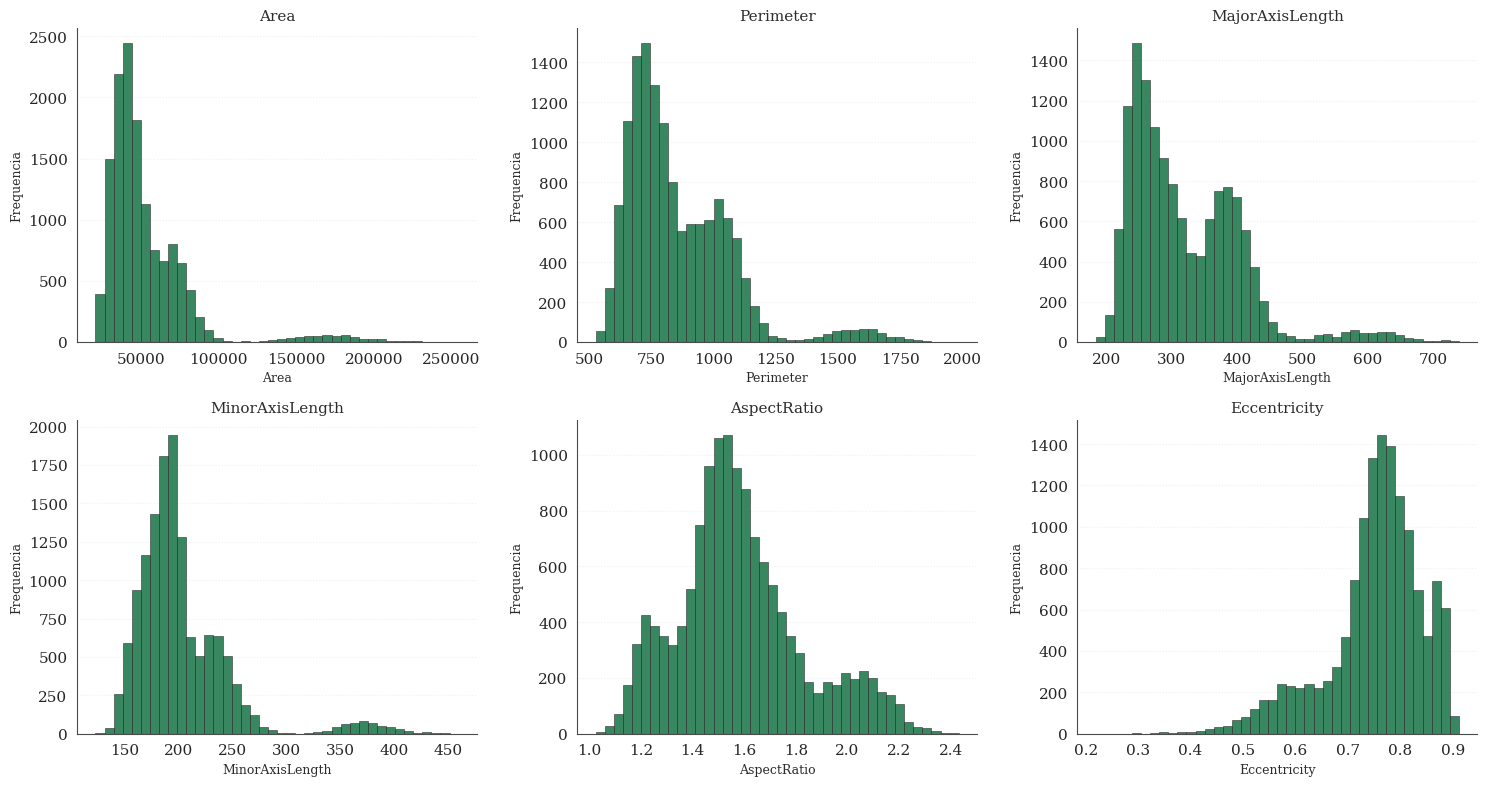

In [10]:
# A grafia do UCI as vezes vem como 'AspectRation' em vez de 'AspectRatio' — trato os dois
if 'AspectRatio' in df.columns:
    feats = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity']
elif 'AspectRation' in df.columns:
    feats = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), feats):
    ax.hist(df[feat], bins=40, color=UNB_VERDE, edgecolor='#2c2c2c',
            linewidth=0.5, alpha=0.78)
    ax.set_title(feat, color='#2c2c2c', fontsize=11)
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('Frequencia', fontsize=9)
    ax.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

Os histogramas confirmam visualmente o que as estatísticas já sugeriam. Area e Perimeter têm uma assimetria forte à direita — a cauda longa onde está o BOMBAY. MajorAxisLength e MinorAxisLength mostram distribuições aparentemente multimodais (vejo dois ou três "morros"), o que provavelmente reflete a estrutura latente das classes — grãos de tamanhos diferentes formam picos diferentes na distribuição agregada.

AspectRatio e Eccentricity, por outro lado, são as mais bem comportadas. Isso é coerente: razões e excentricidades são quantidades adimensionais, naturalmente normalizadas, então não sofrem o mesmo efeito de escala.

A implicação prática dessa assimetria, especialmente em Area, é que vou precisar pensar bem nos limites de especificação (LSL/USL) na hora de calcular os índices de capacidade no próximo entregável. Os índices Cp e Cpk assumem distribuição normal (Montgomery, Cap. 8), e quando essa premissa é violada eles podem subestimar ou superestimar a capacidade real.

### 5.2 Estrutura de correlações

Uma matriz de correlação de Pearson entre todas as 16 features. Quero identificar pares fortemente correlacionados — eles indicam redundância e podem ser problemáticos especialmente para a Regressão Logística (multicolinearidade gera instabilidade nos coeficientes).

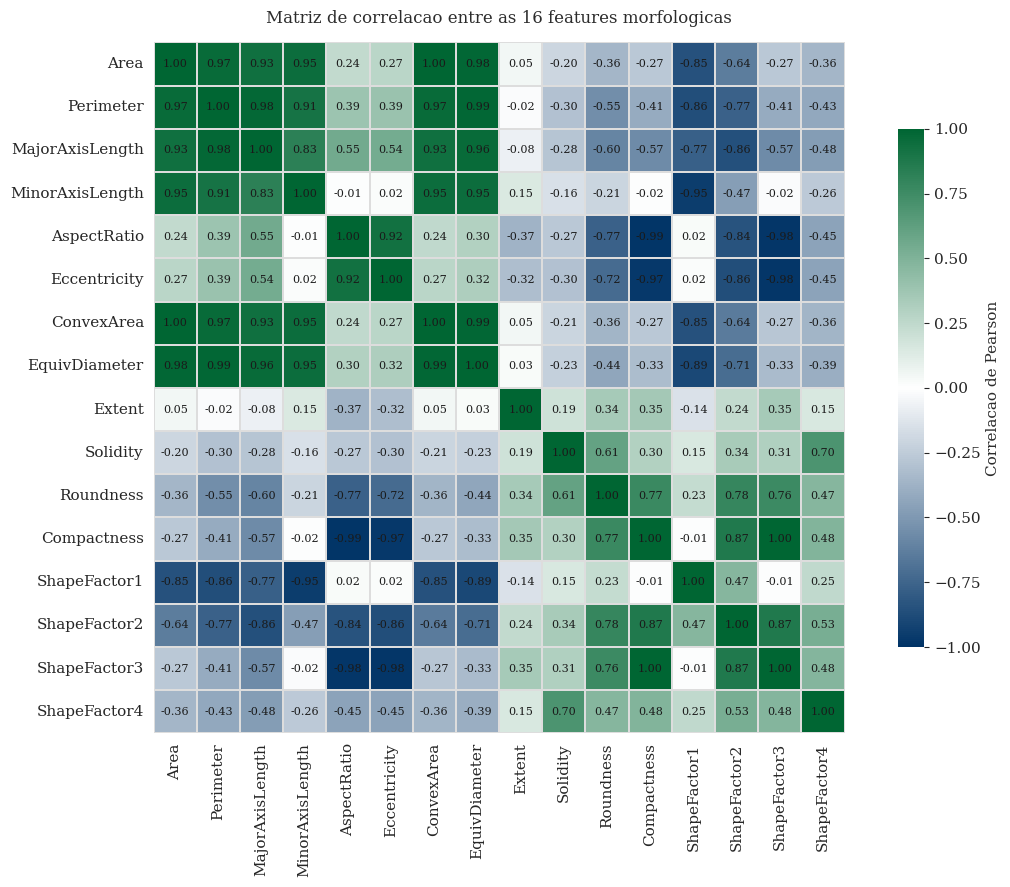

In [11]:
# Paleta divergente em tons da UnB para o heatmap
from matplotlib.colors import LinearSegmentedColormap
cmap_unb = LinearSegmentedColormap.from_list(
    'unb_divergent',
    [UNB_AZUL, '#ffffff', UNB_VERDE],
    N=256
)

plt.figure(figsize=(12, 9))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap_unb, center=0,
            vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.75, 'label': 'Correlacao de Pearson'},
            annot_kws={'size': 8, 'color': '#1a1a1a'},
            linewidths=0.3, linecolor='#dddddd')
plt.title('Matriz de correlacao entre as 16 features morfologicas',
          fontsize=12, color='#2c2c2c', pad=14)
plt.tight_layout()
plt.show()

A matriz revela uma estrutura de correlações esperada, mas com casos extremos que merecem atenção. Os pares mais correlacionados que identifiquei:

Area e ConvexArea têm correlação praticamente perfeita (próxima de 1,00). Isso é matematicamente esperado — a ConvexArea é a área do menor polígono convexo que envolve o grão, e para grãos sem grandes côncavidades os dois valores coincidem.

Area e EquivDiameter também ficam acima de 0,99. O EquivDiameter é, por definição, o diâmetro de um círculo de mesma área que o grão (`EquivDiameter = sqrt(4·Area/π)`), então a relação é determinística.

Perimeter e MajorAxisLength giram em torno de 0,97, e AspectRatio com Eccentricity também ficam acima de 0,95.

Para mim, isso significa que eu não preciso usar todas as 16 features na modelagem — várias estão carregando a mesma informação. Modelos baseados em árvores (Random Forest) lidam bem com multicolinearidade, mas a Regressão Logística vai sofrer. Anoto para experimentar com PCA ou para remover manualmente as features redundantes no próximo entregável.

## 6. O que aprendi nesta primeira inspeção

Esses primeiros testes me deixaram com algumas convicções e algumas dúvidas que vou trabalhar nos próximos entregáveis.

Sobre o dataset em si, ele está mais limpo do que eu esperava — sem ausentes, tipos corretos, sem precisar de tratamento estrutural. O cuidado todo vai estar na **interpretação** das features, não no saneamento.

Sobre as variedades, BOMBAY é o caso que vai exigir mais atenção. Ela representa menos de 4% das amostras e tem tamanho físico muito acima das demais, o que cria três problemas em cascata: (i) ela vai aparecer como outlier em qualquer critério estatístico global, (ii) sua remoção esvazia ainda mais uma classe que já é minoritária, e (iii) métricas de modelagem por classe (precisão, recall) ficam estatisticamente frágeis com tão poucas amostras. Vou considerar tratar outliers por classe em vez de globalmente.

Sobre a estrutura de variáveis, há claramente redundância (especialmente nos pares Area/ConvexArea/EquivDiameter e AspectRatio/Eccentricity). Para o CEP, posso escolher uma de cada grupo. Para o ML, vou deixar tudo no Random Forest (que tolera) mas pensar em PCA para a Regressão Logística.

Sobre o que vem a seguir, no próximo entregável faço as cartas X-barra e R para pelo menos duas variáveis (provavelmente MajorAxisLength e Area, que têm mais informação útil), os índices Cp, Cpk, Pp e Ppk com os limites de especificação que vou justificar com base no que é típico do mercado de classificação comercial de feijão. Depois vem a modelagem com Regressão Logística, Random Forest e SVM, GridSearchCV e a discussão dos erros por classe — com atenção especial ao BOMBAY.

---

*Notebook executado no Google Colab. Código e dados versionados em https://github.com/melobomontenegro-dev/CEP_Projeto_Maria_Eduarda*